In [7]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression

In [4]:
X,y = make_regression(n_samples=100, n_features =1, n_informative=1,n_targets=1,noise=20, random_state=13)

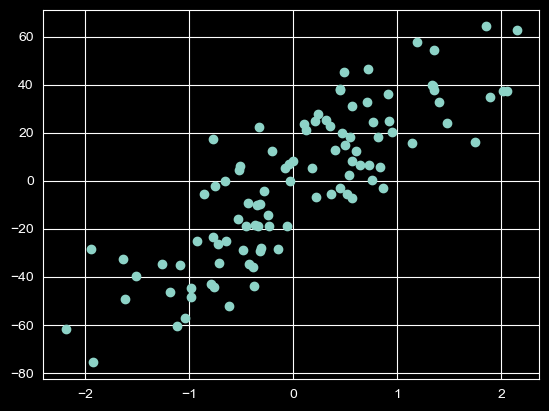

In [5]:
plt.scatter(X,y)

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [8]:
lr = LinearRegression()

In [9]:
lr.fit(X_train,y_train)
print(lr.coef_)
print(lr.intercept_)

[28.12597332]
-2.271014426178382


In [10]:
y_pred = lr.predict(X_test)
from sklearn.metrics import r2_score
print(r2_score(y_test,y_pred))

0.6345158782661013


In [13]:
class GDRegressor:
    def __init__(self,learning_rate, epochs):
        self.m = 100
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self,X,y):
        for i in range(self.epochs):
            loss_slope_b = -2 * np.sum(y-self.m*X.ravel() - self.b)
            loss_slope_m = -2 * np.sum((y-self.m*X.ravel() - self.b)*X.ravel())

            self.b = self.b - (self.lr*loss_slope_b)
            self.m = self.m - (self.lr*loss_slope_m)

        print(self.m,self.b)

    def predict(self, X):
        return self.m * X + self.b

In [14]:
gd = GDRegressor(0.001,50)
gd.fit(X_train,y_train)
y_pred = gd.predict(X_test)

r2_score(y_test,y_pred)

28.159367347119066 -2.3004574196824854


0.6343842836315579